In [1]:
import ee
from RadGEEToolbox import GenericCollection, get_palette
from GEE_UBM import InputCollections, build_model_ready_collection, OriginalUBMRun, ModifiedUBM1Run, check_merged_collection, SnowMelt
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import pandas as pd
import os

In [2]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

In [3]:
UBM_assets = ['projects/ut-gee-ugs-bsf-dev/assets/ModifiedUBM1Runs/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_PRISMSNOM_ETDALEXI_IRRIm_M_mm',
              'projects/ut-gee-ugs-bsf-dev/assets/ModifiedUBM1Runs/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_PRISMSNOM_ETEMTRIC_IRRIm_M_mm',
              'projects/ut-gee-ugs-bsf-dev/assets/ModifiedUBM1Runs/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_PRISMSNOM_ETGSEBAL_IRRIm_M_mm',
              'projects/ut-gee-ugs-bsf-dev/assets/ModifiedUBM1Runs/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_PRISMSNOM_ETPTJPL_IRRIm_M_mm',
              'projects/ut-gee-ugs-bsf-dev/assets/ModifiedUBM1Runs/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_PRISMSNOM_ETSBOP_IRRIm_M_mm']

UT_regional_boundary = ee.FeatureCollection('projects/ut-gee-ugs-bsf-dev/assets/Utah_Regional_Boundary').geometry()

In [4]:
collections = [ee.ImageCollection(asset) for asset in UBM_assets]

# Convert each collection to a list for index-based access
col_lists = [col.toList(col.size()) for col in collections]

# Map over indices of the first collection
n = collections[0].size()
indices = ee.List.sequence(0, n.subtract(1))

def mean_at_index(i):
    i = ee.Number(i).toInt()
    # Grab the i-th image from each collection
    images_at_i = [ee.Image(col_list.get(i)) for col_list in col_lists]
    mean_img = ee.ImageCollection(images_at_i).mean().setDefaultProjection(crs='EPSG:32612', scale=4638.312116423505)
    # Preserve time metadata from the first collection's image
    first = ee.Image(col_lists[0].get(i))
    return mean_img.copyProperties(first, first.propertyNames())

mean_collection = ee.ImageCollection(indices.map(mean_at_index))

In [5]:
start_date = '2016-01-01'
end_date = '2023-11-30'

In [6]:
print(mean_collection.first().bandNames().getInfo())
print(mean_collection.first().projection().nominalScale().getInfo())

mean_collection_gc = GenericCollection(collection=mean_collection, start_date=start_date, end_date=end_date)

['precip_and_snowmelt_input', 'irrigation', 'AET', 'soil_thickness', 'soil_porosity', 'field_capacity', 'wilting_point', 'Geo_K', 'Runoff', 'Recharge', 'Soil_Water_End_Of_Previous_Timestep', 'Soil_Saturation_Percent_End_Of_Timestep']
4638.312116423505


In [7]:
mean_collection_gc_yearly = mean_collection_gc.yearly_mean_collection()

In [8]:
print(mean_collection_gc_yearly.dates)

['2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01']


In [9]:
# col_index = 2
# UBM_col = ee.ImageCollection(UBM_assets[col_index])
# soil_sat_band_name = UBM_col.first().bandNames().getInfo()[-1]
target_proj = ee.ImageCollection("NASA/SMAP/SPL3SMP_E/005").select('soil_moisture_am').first().projection()
def reproject(image):
    return image.reduceResolution(reducer=ee.Reducer.mean(), maxPixels=64).reproject(crs=target_proj)
# soil_sat_col = GenericCollection(collection=UBM_col.select(soil_sat_band_name), start_date='2015-04-01', end_date='2023-11-30')
soil_sat_col = GenericCollection(collection=mean_collection_gc.collection.select('Soil_Saturation_Percent_End_Of_Timestep').map(reproject))
soil_sat_col_yearly = GenericCollection(collection=mean_collection_gc_yearly.collection.select('Soil_Saturation_Percent_End_Of_Timestep').map(reproject))
dates = soil_sat_col.dates
# print(soil_sat_band_name)
print(dates)
print(len(dates))

['2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01', '2021-11-01', '2021

In [10]:
smap_col = ee.ImageCollection("NASA/SMAP/SPL3SMP_E/005").select('soil_moisture_am')
# smap_col = GenericCollection(collection=smap_col, start_date='2015-04-01', end_date='2023-11-30').monthly_mean_collection.mask_to_polygon(UT_regional_boundary)
smap_col = GenericCollection(collection=smap_col, start_date=start_date, end_date=end_date).monthly_mean_collection.mask_to_polygon(UT_regional_boundary)
smap_col_yearly = smap_col.yearly_mean_collection()
print(smap_col.dates)

['2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01', '2021-11-01', '2021

In [49]:
print(smap_col_yearly.dates)

['2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01']


In [27]:
smap_max = GenericCollection(collection=smap_col, start_date='2015-04-01', end_date='2023-11-30').max.clip(UT_regional_boundary)
def normalize(img):
    return img.divide(smap_max).multiply(100).copyProperties(img, img.propertyNames())
smap_col_normalized = GenericCollection(collection=smap_col.collection.map(lambda img: normalize(img)))

In [12]:
print(len(smap_col.dates))

13


In [54]:
index = -3
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
Map.addLayer(soil_sat_col_yearly.image_grab(index), vis_params={'bands':['Soil_Saturation_Percent_End_Of_Timestep'], 'min':0, 'max':100, 'palette':get_palette('rdylbu')}, name='UBM Soil Sat')
Map.addLayer(smap_col_yearly.image_grab(index), vis_params={'bands':['soil_moisture_am'], 'min':0, 'max':0.4, 'palette':get_palette('rdylbu')}, name='SMAP Soil Sat')

print(dates[index])
print(smap_col.dates[index])
Map

2023-09-01
2023-09-01


Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [44]:
# index = -2
# Map = geemap.Map(center=[39.5, -111.5], zoom=7)
# Map.addLayer(soil_sat_col.image_grab(index), vis_params={'bands':['Soil_Saturation_Percent_End_Of_Timestep'], 'min':0, 'max':100, 'palette':get_palette('rdylbu')}, name='UBM Soil Sat')
# Map.addLayer(smap_col_normalized.image_grab(index), vis_params={'bands':['soil_moisture_am'], 'min':40, 'max':100, 'palette':get_palette('rdylbu')}, name='SMAP Soil Sat')

# print(dates[index])
# print(smap_col.dates[index])
# Map

In [11]:
def calculate_climatological_anomaly(
    collection, 
    baseline_start_year, 
    baseline_end_year, 
    band_name='Soil_Saturation_Percent_End_Of_Timestep',
    anomaly_band_name='Saturation_Anomaly_Climatological',
    debug=True
):
    """
    Calculates the anomaly relative to a long-term monthly climatology.
    """
    
    # 1. Establish the Baseline Collection
    baseline_col = collection.filter(
        ee.Filter.calendarRange(baseline_start_year, baseline_end_year, 'year')
    ).select(band_name)
    
    # 2. Compute Climatology (One image per month 1-12)
    months = ee.List.sequence(1, 12)
    
    def compute_month_mean(m):
        # Filter for the specific month
        monthly_subset = baseline_col.filter(ee.Filter.calendarRange(m, m, 'month'))
        
        # Calculate mean
        mean_img = monthly_subset.mean().set('month', m)
        
        # Capture the dates used for this specific month's mean
        # We aggregate the 'Date_Filter' (or system:time_start) to a list
        dates_used = monthly_subset.aggregate_array('Date_Filter')
        
        return mean_img.set('clim_dates_used', dates_used)

    climatology = ee.ImageCollection.fromImages(months.map(compute_month_mean))
    
    # 3. Join Climatology to Input
    col_with_month = collection.map(lambda img: img.set('month', img.date().get('month')))
    
    filter_month = ee.Filter.equals(leftField='month', rightField='month')
    join = ee.Join.saveFirst(matchKey='clim_ref')
    joined_col = ee.ImageCollection(join.apply(col_with_month, climatology, filter_month))
    
    # 4. Calculate Anomaly
    def compute_anomaly(img):
        clim_img = ee.Image(img.get('clim_ref'))
        val = img.select(band_name)
        
        anom = val.subtract(clim_img).rename(anomaly_band_name)
        res = img.addBands(anom)
        
        if debug:
            # Pass the list of dates from the climatology image to the result
            res = res.set('DEBUG_clim_dates_used', clim_img.get('clim_dates_used'))
            res = res.set('DEBUG_clim_month_used', clim_img.get('month'))
            
        return res
    
    return ee.ImageCollection(joined_col.map(compute_anomaly))

def calculate_rolling_anomaly(
    collection, 
    window_months=3, 
    band_name='Soil_Saturation_Percent_End_Of_Timestep',
    anomaly_band_name='Saturation_Anomaly_Rolling',
    debug=True
):
    """
    Calculates the anomaly relative to the mean of the PREVIOUS N months.
    """
    
    # 1. Select band early for memory efficiency
    history_col = collection.select([band_name])
    
    # 2. Define the Rolling Window Filter
    # We want [Current - Window] < History < Current
    
    # Calculate window in milliseconds (adding buffer for irregular month lengths)
    # 3 months * 32 days/month
    window_millis = window_months * 32 * 24 * 60 * 60 * 1000
    
    filter_window = ee.Filter.And(
        # CRITICAL FIX: greaterThan means "Target Time > Candidate Time"
        # This ensures we select images in the PAST.
        ee.Filter.greaterThan(leftField='system:time_start', rightField='system:time_start'),
        
        # Must be within the window duration
        ee.Filter.maxDifference(
            difference=window_millis,
            leftField='system:time_start',
            rightField='system:time_start'
        )
    )
    
    # 3. Join History to Current
    join = ee.Join.saveAll(
        matchesKey='history_imgs',
        ordering='system:time_start',
        ascending=False # Sorts Newest -> Oldest (e.g., June, May, April)
    )
    
    joined_col = ee.ImageCollection(join.apply(collection, history_col, filter_window))
    
    # 4. Calculate Anomaly
    def compute_rolling_diff(img):
        history_list = ee.List(img.get('history_imgs'))
        history_size = history_list.size()
        
        # --- LOGIC TO HANDLE INSUFFICIENT DATA ---
        # We only calculate the mean if we have enough history (size >= window)
        # Otherwise, we assume the anomaly is 0 (neutral).
        
        # 1. Create collection from history
        history_cloud = ee.ImageCollection.fromImages(history_list)
        
        # 2. Calculate Mean of history
        prev_mean = history_cloud.mean()
        
        # 3. Calculate Raw Anomaly
        current_val = img.select(band_name)
        raw_anom = current_val.subtract(prev_mean).rename(anomaly_band_name)
        
        # 4. Check condition: Do we have enough images?
        has_enough_data = history_size.gte(window_months)
        
        # 5. Apply Condition
        # If we have enough data, use the calculated anomaly.
        # If NOT, use a constant image of 0.
        final_anom = raw_anom.where(has_enough_data.Not(), 0)

        # Add the band
        res = img.addBands(final_anom)

        if debug:
            # Add debug info
            date_list = history_cloud.aggregate_array('Date_Filter')
            res = res.set('DEBUG_rolling_dates_used', date_list)
            res = res.set('DEBUG_rolling_count', history_size)
            res = res.set('DEBUG_sufficient_history', has_enough_data)
        
        return res
        
    return ee.ImageCollection(joined_col.map(compute_rolling_diff))

In [12]:
# soil_sat_col = GenericCollection(collection=UBM_col, start_date='2005-01-01', end_date='2025-01-30') #.select(soil_sat_band_name).map(reproject)
mean_collection_gc_all = GenericCollection(collection=mean_collection.select('Soil_Saturation_Percent_End_Of_Timestep'), start_date='2016-01-01', end_date='2023-12-31')
soil_sat_col_clim_anomaly = calculate_climatological_anomaly(collection=mean_collection_gc_all.collection, baseline_start_year=2016, baseline_end_year=2023)
soil_sat_col_clim_anomaly = GenericCollection(soil_sat_col_clim_anomaly, start_date=start_date, end_date=end_date)
print(soil_sat_col_clim_anomaly.dates)
print(soil_sat_col_clim_anomaly.collection.first().bandNames().getInfo())
print(soil_sat_col_clim_anomaly.collection.first().getInfo()['properties'])

['2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01', '2021-11-01', '2021

In [13]:
smap_clim_anomaly = GenericCollection(collection=calculate_climatological_anomaly(collection=smap_col.collection, baseline_start_year=2016, baseline_end_year=2023, band_name='soil_moisture_am'))
print(smap_clim_anomaly.dates)

['2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01', '2021-11-01', '2021

In [61]:
# soil_sat_col_temporal_anomaly = calculate_rolling_anomaly(collection=soil_sat_col.collection, band_name='Soil_Saturation_Percent_End_Of_Timestep')
# soil_sat_col_temporal_anomaly = GenericCollection(soil_sat_col_temporal_anomaly)
# print(soil_sat_col_temporal_anomaly.dates)
# print(soil_sat_col_temporal_anomaly.collection.first().bandNames().getInfo())
# print(soil_sat_col_temporal_anomaly.image_grab(-12).getInfo()['properties'])

In [14]:
ubm_soil_clim_dates = soil_sat_col_clim_anomaly.dates
smap_soil_clim_dates = smap_clim_anomaly.dates

In [15]:
index = -1
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
# Map.addLayer(soil_sat_col_clim_anomaly.image_grab(index), vis_params={'bands':[soil_sat_band_name], 'min':0, 'max':100, 'palette':get_palette('rdylbu')}, name='UBM Soil Sat')
# Map.addLayer(soil_sat_col_clim_anomaly.image_grab(index), vis_params={'bands':[soil_sat_band_name], 'min':0, 'max':50, 'palette':['brown', 'tan', 'green']}, name='UBM Soil Sat')

Map.addLayer(soil_sat_col_clim_anomaly.image_grab(index), vis_params={'bands':['Saturation_Anomaly_Climatological'], 'min':-40, 'max':40, 'palette':get_palette('rdbu')}, name='Monthly Anomaly UBM')
Map.addLayer(smap_clim_anomaly.image_grab(index), vis_params={'bands':['Saturation_Anomaly_Climatological'], 'min':-0.1, 'max':0.1, 'palette':get_palette('rdbu')}, name='Monthly Anomaly SMAP')


# Map.addLayer(soil_sat_col_temporal_anomaly.image_grab(index), vis_params={'bands':['Saturation_Anomaly_Rolling'], 'min':-50, 'max':50, 'palette':get_palette('rdbu')}, name='3-Month Anomaly')

print(ubm_soil_clim_dates[index])
print(smap_soil_clim_dates[index])
Map

2023-11-01
2023-11-01


Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [25]:
import math
from geemap import cartoee
import cartopy.crs as ccrs

def plot_cartoee_grid(images, region, dates, vis_params, figsize, ncols, add_gridlines=False, save_path=None, cmap='inferno', 
                      colorbar=True, colorbar_loc='right', colorbar_label='Value', wspace=0.025, hspace=0.025, 
                      annotate_date=True, annotate_xy=(0.22, 0.96), annotate_fontsize=8, annotate_color='white', 
                      annotate_bgcolor='black', annotate_alpha=0.7, tight_layout=False, grid_nticks=4, add_scalebar=True, scalebar_length=100, scalebar_xy=(0.05, 0.05),
                        add_highways=True, highway_color='black', highway_width=2):
    """Plot a grid of Earth Engine images using Cartopy and Matplotlib. 

    Args: 
        images (list or ee.ImageCollection): A list of ee.Image objects or a single ee.ImageCollection to plot.
        region (ee.Geometry): The region to plot (should be a ee.Geometry object).
        dates (list): A list of date strings corresponding to each image for annotation.
        vis_params (dict): Visualization parameters for the images (e.g., {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.9}).
        figsize (tuple): Figure size in inches (width, height).
        ncols (int): Number of columns in the grid.
        add_gridlines (bool, optional): Whether to add gridlines to each subplot. Defaults to False.
        save_path (str, optional): If provided, saves the figure to this path (without extension). Defaults to None.
        cmap (str, optional): Colormap to use for single-band images. Defaults to 'inferno'.
        colorbar (bool, optional): Whether to add a colorbar for single-band images. Defaults to True.
        colorbar_loc (str, optional): Location of the colorbar (e.g., 'right', 'bottom'). Defaults to 'right'.
        colorbar_label (str, optional): Label for the colorbar. Defaults to 'Value'.
        wspace (float, optional): Width space between subplots. Defaults to 0.025.
        hspace (float, optional): Height space between subplots. Defaults to 0.025.
        annotate_date (bool, optional): Whether to annotate the date on each subplot. Defaults to True.
        annotate_xy (tuple, optional): Coordinates for date annotation in axes fraction. Defaults to (0.22, 0.96).
        annotate_fontsize (int, optional): Font size for date annotation. Defaults to 8.
        annotate_color (str, optional): Text color for date annotation. Defaults to 'white'.
        annotate_bgcolor (str, optional): Background color for date annotation. Defaults to 'black'.
        annotate_alpha (float, optional): Background transparency for date annotation. Defaults to 0.7.
        tight_layout (bool, optional): Whether to use tight layout for the figure. Defaults to False.

    Returns:
        None: Displays the figure and optionally saves it to disk.

    Raises:
        ValueError: If input parameters are not of the expected type or if lengths of images and dates do not match, or if visualization parameters are not properly defined.

    """
    # import cartopy.crs as ccrs
    # import matplotlib.pyplot as plt
    # import math

    if isinstance(images, ee.ImageCollection):
        # We must pull the collection into a LOCAL Python list of ee.Image objects
        count = images.size().getInfo()
        ee_list = images.toList(count)
        images = [ee.Image(ee_list.get(i)) for i in range(count)]
    elif isinstance(images, list):
        if not all(isinstance(img, ee.Image) for img in images):
            raise ValueError("All items in the 'images' list must be ee.Image objects.")
    else:
        raise ValueError("'images' must be a list of ee.Image objects or an ee.ImageCollection.")
    # check if region is an ee.Geometry
    if not isinstance(region, ee.Geometry):
        raise ValueError("The 'region' parameter must be an ee.Geometry object.")
    # check if dates is a list
    if not isinstance(dates, list):
        raise ValueError("The 'dates' parameter must be a list of date strings corresponding to the images.")
    # check if lenth of images and dates match
    if len(images) != len(dates):
        raise ValueError("The length of 'images' and 'dates' lists must match.")
    # check number of bands in vis_params
    band_count = len(vis_params.get('bands', []))
    if band_count == 0:
        raise ValueError("The 'vis_params' must include a 'bands' key with a list of band names to visualize.")
    if band_count == 1:
        image_type = 'single_band'
    elif band_count == 3:
        image_type = 'rgb'
    else:
        raise ValueError("The 'vis_params' must include either 1 band for single_band or 3 bands for rgb visualization.")
    
    number_of_images = len(images)
    nrows = math.ceil(number_of_images / ncols)

    coords = region.bounds().coordinates().getInfo()[0]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]

    # Force true min/max to guarantee West, East, South, North
    lon_min, lon_max = min(lons), max(lons) 
    lat_min, lat_max = min(lats), max(lats) 

    # 2. STANDARD geemap region: [West, South, East, North]
    my_region = [lon_min, lat_min, lon_max, lat_max]
    cartopy_extent = [lon_max, lon_min, lat_min, lat_max]
    center_lat = (lat_min + lat_max) / 2
    aspect_ratio = 1 / math.cos(math.radians(center_lat))

    my_proj = ccrs.PlateCarree()
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13, 6.5), subplot_kw={'projection': my_proj}, sharex=True, sharey=True)
    axs = axs.flatten()  # Flatten to easily iterate over
    titles = [f'{dates[i]}' for i in range(0, len(dates))]
    vis = vis_params
    for i, ax in enumerate(axs):
        
        if image_type == 'rgb':
            cartoee.add_layer(ax, images[i], region=my_region, vis_params=vis)
        else: 
            cartoee.add_layer(ax, images[i], region=my_region, vis_params=vis, cmap=cmap)

        if add_highways:
            # Filter TIGER roads for primary highways (S1100)
            highways_fc = ee.FeatureCollection("TIGER/2016/Roads").filter(ee.Filter.eq('mtfcc', 'S1100'))
            
            # Paint the feature collection to a raster (much faster than drawing vectors locally)
            empty_img = ee.Image().byte()
            highways_img = empty_img.paint(highways_fc, 1, highway_width)
            
            # Mask out everything except the roads, so the background remains transparent
            highways_img = highways_img.updateMask(highways_img.eq(1))
            
            cartoee.add_layer(ax, highways_img, region=my_region, vis_params={'palette': [highway_color]})

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        if add_gridlines:
            cartoee.add_gridlines(ax, n_ticks=grid_nticks, draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, buffer_out=True)
        
        if add_scalebar:
            cartoee.add_scale_bar_lite(
                ax, 
                length=scalebar_length, 
                xy=scalebar_xy, 
                fontsize=10, 
                color='black',  # Change to black if your base map is light
                linewidth=2, 
                unit='km'
            )

        

        # Apply our fixes to this specific axis
        ax.set_aspect(aspect_ratio)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        if annotate_date:
            ax.annotate(f"{titles[i]}", xy=annotate_xy, xycoords='axes fraction', ha='center', va='top', fontsize=annotate_fontsize, color=annotate_color, backgroundcolor=annotate_bgcolor, alpha=annotate_alpha)

    if colorbar and image_type == 'single_band':
        cartoee.add_colorbar(
            axs[0], 
            vis_params=vis, 
            cmap=cmap, 
            loc=colorbar_loc, 
            label=colorbar_label
        )
    fig.subplots_adjust(wspace=wspace, hspace=hspace)
    if tight_layout:
        fig.tight_layout()
    if save_path:
        # plt.savefig(save_path+'.jpg', dpi=300)
        # plt.savefig(save_path+'.png', dpi=300)
        plt.savefig(save_path+'.svg', dpi=300)
    plt.show()

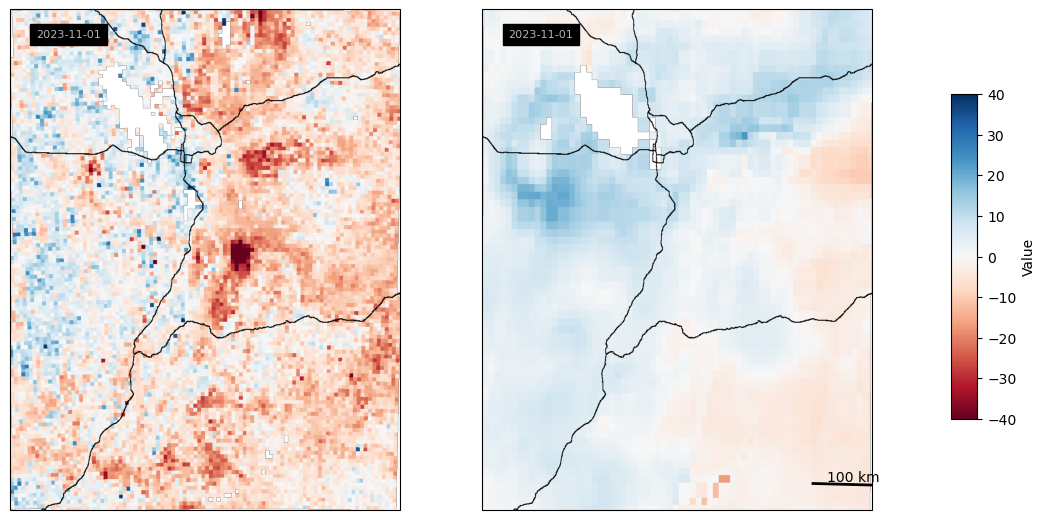

In [ ]:
plot_cartoee_grid(images=[soil_sat_col_clim_anomaly.image_grab(index), smap_clim_anomaly.image_grab(index).multiply(400)], region=UT_regional_boundary, dates=[ubm_soil_clim_dates[index], smap_soil_clim_dates[index]],
                  vis_params={'bands':['Saturation_Anomaly_Climatological'], 'min':-40, 'max':40}, cmap='RdBu', ncols=2, figsize=(6, 4), annotate_xy=(0.15, 0.96), wspace=0.005, hspace=0.01,
                  save_path='C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Climate_and_Validation_Figures\\UBM_Post_Calibration_Figures\\UBM_vs_SMAP_anomaly_Nov_2023', add_highways=False, add_scalebar=False)